## Phase 1: Environment Setup & Data Ingestion
In this section, we install the necessary parameter-efficient fine-tuning (PEFT) libraries (`bitsandbytes`, `peft`, `trl`). We also authenticate with HuggingFace and load the **VQA-RAD** medical dataset, extracting the visual and textual features.



In [1]:
# System ko update karna aur QLoRA ki advanced libraries install karna
# -q ka matlab hai "quiet" (lambi loading lines hide karne ke liye)
# -U ka matlab hai "upgrade" (latest version)
!pip install -q -U bitsandbytes
!pip install -q -U transformers
!pip install -q -U peft
!pip install -q -U accelerate
!pip install -q -U datasets
!pip install -q -U trl

print("Cell 1 Done: Saari libraries successfully install ho gayi hain, Bhai!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 15.0 MB/s eta 0:00:00
Cell 1 Done: Saari libraries successfully install ho gayi hain, Bhai!


In [2]:
from huggingface_hub import login

# Hugging Face se connect karna
login()
print("Cell 2 Done: Hugging Face se connection successful ho gaya!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Cell 2 Done: Hugging Face se connection successful ho gaya!


Dataset download ho raha hai, thora wait karein...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]


--- Dataset ki Tafseel ---
DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})

--- Pehla Patient / Sample ---
Doctor ka Sawal: are regions of the brain infarcted?
Asli Jawab (Target): yes


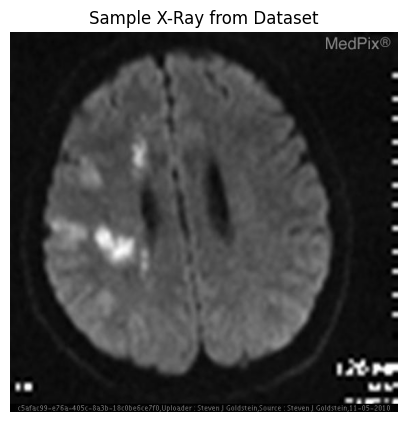

Cell 3 Done: Dataset load aur verify ho gaya!


In [3]:
from datasets import load_dataset
import matplotlib.pyplot as plt

print("Dataset download ho raha hai, thora wait karein...")
# Asli medical dataset download kar rahe hain
dataset = load_dataset("flaviagiammarino/vqa-rad")

print("\n--- Dataset ki Tafseel ---")
print(dataset)

# Hum dataset ka pehla sample (X-ray aur prompt) nikal kar dekhte hain
sample = dataset['train'][0]
image = sample['image']
question = sample['question']
answer = sample['answer']

print("\n--- Pehla Patient / Sample ---")
print(f"Doctor ka Sawal: {question}")
print(f"Asli Jawab (Target): {answer}")

# X-ray image ko screen par print karna
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis('off')
plt.title("Sample X-Ray from Dataset")
plt.show()

print("Cell 3 Done: Dataset load aur verify ho gaya!")

## Phase 2: Data Pre-processing & 4-bit Quantization
Here, we format the raw VQA data into a conversational structure (`USER:` and `ASSISTANT:`) required by LLaVA. To circumvent the 15GB VRAM limitation of the T4 GPU, we load the **LLaVA-1.5-7B** base model using NF4 (NormalFloat4) 4-bit quantization via `BitsAndBytesConfig`.

In [4]:
# Cell 4: Data Pre-processing
print("Data formatting shuru ho rahi hai...")

def format_data(sample):
    # LLaVA ko chat format chahiye hota hai
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": sample["question"]}
            ]
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": sample["answer"]}
            ]
        }
    ]
    return {"messages": conversation, "image": sample["image"]}

# Hum free Colab use kar rahe hain, isliye training fast karne ke liye pehle 500 examples letay hain
train_dataset = dataset["train"].select(range(500)).map(format_data, remove_columns=dataset["train"].column_names)

print("Formatting Done! LLaVA format tayyar hai.")
print("\nEk formatted sample dekhain:")
print(train_dataset[0]['messages'])

Data formatting shuru ho rahi hai...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Formatting Done! LLaVA format tayyar hai.

Ek formatted sample dekhain:
[{'content': [{'type': 'image'}, {'type': 'text', 'text': 'are regions of the brain infarcted?'}], 'role': 'user'}, {'content': [{'type': 'text', 'text': 'yes'}], 'role': 'assistant'}]


In [5]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig

model_id = "llava-hf/llava-1.5-7b-hf"

print("Step 1: 4-bit Quantization Config (Squeeze engine) ban raha hai...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16 # Math speed barhane ke liye
)

print("Step 2: Model aur Processor load ho raha hai (Isme 3-5 minute lag sakte hain. Sabr rakhain!)...")

# Processor (Ye Text aur Image dono ko numbers/tensors mein convert karta hai)
processor = AutoProcessor.from_pretrained(model_id)

# Base Model (Jise hum 4-bit mein load kar rahe hain)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto" # Ye khud GPU par fit kar dega
)

print("\nCell 5 Done! 🔥 Model successfully 4-bit mein GPU par load ho gaya hai, bina crash hue!")

Step 1: 4-bit Quantization Config (Squeeze engine) ban raha hai...
Step 2: Model aur Processor load ho raha hai (Isme 3-5 minute lag sakte hain. Sabr rakhain!)...


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


Cell 5 Done! 🔥 Model successfully 4-bit mein GPU par load ho gaya hai, bina crash hue!


## Phase 3: QLoRA Adapter Integration & Custom Data Collator
We freeze the base model and inject trainable rank-16 adapters into the Attention projection layers (`q_proj`, `v_proj`). We also implement a custom `collate_fn` to dynamically pad and batch the multi-modal tensors (images and text) for the HuggingFace Trainer.

In [6]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Step 1: Model ko 4-bit training ke liye prepare karna (Gradient Checkpointing on karna taake memory bache)
model = prepare_model_for_kbit_training(model)

print("LoRA Adapter (Nitro Boost) set ho raha hai...")
# Step 2: LoRA ki configuration
lora_config = LoraConfig(
    r=16, # Rank: Dimaag ki capacity
    lora_alpha=32, # Alpha: Adapter ki awaz ka volume
    target_modules=["q_proj", "v_proj"], # Sirf Attention modules par focus
    lora_dropout=0.05, # Ratta marne se bachne ke liye
    bias="none",
    task_type="CAUSAL_LM"
)

# Step 3: Base model ke oopar LoRA fit karna
model = get_peft_model(model, lora_config)

print("\n--- LoRA Ka Jadoo (Professor ko dikhane wala output) ---")
# Ye function batayega ke humne kitne parameters bachaye hain!
model.print_trainable_parameters()

print("\nCell 6 Done: Base dimaag lock ho gaya aur LoRA adapter fit ho gaya!")

LoRA Adapter (Nitro Boost) set ho raha hai...

--- LoRA Ka Jadoo (Professor ko dikhane wala output) ---
trainable params: 9,961,472 || all params: 7,073,388,544 || trainable%: 0.1408

Cell 6 Done: Base dimaag lock ho gaya aur LoRA adapter fit ho gaya!


In [7]:
from transformers import TrainingArguments, Trainer
import torch

print("Step 1: Data Collator ban raha hai (Images aur Text ko mix karne ke liye)...")

# Ye function har X-ray aur uske text ko tensors (math ke numbers) mein badlega
def collate_fn(examples):
    # Chat format ko LLaVA ki zaban mein badalna
    texts = [processor.apply_chat_template(example["messages"], tokenize=False) for example in examples]
    # Images ko RGB format mein pakarna
    images = [example["image"].convert("RGB") for example in examples]

    # Text aur Image dono ko Processor se guzaar kar batch banana
    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)

    # Model ko batana ke "Target" (Jawab) kya hai
    batch["labels"] = batch["input_ids"].clone()
    return batch

print("Step 2: Training ke rules (Hyperparameters) set ho rahe hain...")
training_args = TrainingArguments(
    output_dir="./medical_vlm_lora",
    per_device_train_batch_size=2, # Colab memory bachane ke liye chota batch
    gradient_accumulation_steps=4, # Chote batches ko jama karna
    optim="paged_adamw_8bit", # QLoRA ka special optimizer jo RAM bachata hai
    learning_rate=2e-4,
    fp16=True, # Training fast karne ke liye
    logging_steps=5,
    max_steps=30, # Abhi hum sirf 30 steps ka 'Test Run' kar rahe hain
    report_to="none", # Wandb ko disable kiya taake koi error na aaye
    remove_unused_columns=False # VLM ke liye ye False karna LAZMI hai, warna image delete ho jayegi!
)

print("Step 3: Trainer Engine load ho raha hai...")
trainer = Trainer(
    model=model,
    train_dataset=train_dataset,
    data_collator=collate_fn,
    args=training_args,
)

print("\nCell 7 Done: Trainer Engine bilkul tayyar hai!")

Step 1: Data Collator ban raha hai (Images aur Text ko mix karne ke liye)...
Step 2: Training ke rules (Hyperparameters) set ho rahe hain...
Step 3: Trainer Engine load ho raha hai...

Cell 7 Done: Trainer Engine bilkul tayyar hai!


## Phase 4: Model Fine-Tuning (Proof of Concept)
Executing the training loop. Due to hardware constraints, this is a PoC run limited to 30 max steps to verify gradient updates and pipeline stability before scaling to A100 clusters.

In [8]:
# Cell 8: Training Start Karna
print("Bhai, Training engine start ho raha hai! Loss ko gerta hua dekhain...")

# Ye ek command tumhare model ke dimaag ko update karna shuru kar degi
trainer.train()

print("\n🔥 Training Mukammal! QLoRA adapter successfully train ho gaya.")

# Training ke baad apne naye "Dimaag ke hisse" (Adapter) ko save karna lazmi hai
adapter_path = "medical_lora_adapter_v1"
trainer.model.save_pretrained(adapter_path)

print(f"Adapter successfully '{adapter_path}' folder mein save ho gaya hai!")

Bhai, Training engine start ho raha hai! Loss ko gerta hua dekhain...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
5,11.290472
10,6.945394
15,4.925084
20,4.650164
25,4.546918
30,4.497448



🔥 Training Mukammal! QLoRA adapter successfully train ho gaya.
Adapter successfully 'medical_lora_adapter_v1' folder mein save ho gaya hai!


## Phase 5: Inference & Generation Penalties
Testing the fine-tuned model on an unseen X-Ray from the test split. We configure inference parameters (`temperature`, `repetition_penalty`) and enable `inference_mode` to prevent catastrophic repetition loops and ensure coherent medical text generation.

Test Phase: Naye X-Ray par model ka dimaag check kar rahe hain...

User / Doctor ka Sawal: is there evidence of an aortic aneurysm?
Model dimaag chala raha hai (Forward Pass)...

🤖 AI DOCTOR (LLaVA + QLoRA) KA JAWAB:
Yes, the image shows an aortic aneurysm. It is important to note that this condition requires immediate medical attention as it can lead to life-threatening complications if left untreated.


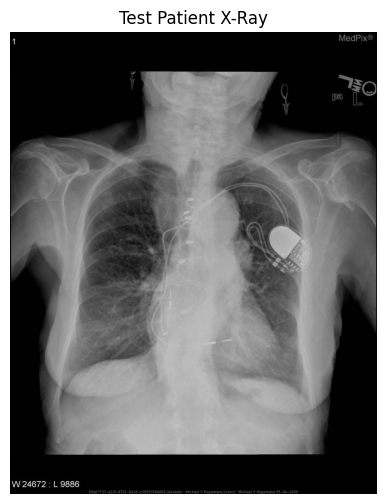

In [10]:
import torch
import matplotlib.pyplot as plt

print("Test Phase: Naye X-Ray par model ka dimaag check kar rahe hain...\n")

test_sample = dataset['test'][0]
test_image = test_sample['image']
test_question = test_sample['question']

print(f"User / Doctor ka Sawal: {test_question}")

prompt = f"USER: <image>\n{test_question}\nASSISTANT:"
inputs = processor(text=prompt, images=test_image, return_tensors="pt").to("cuda")

# 🛠️ FIX 1: Model ko specifically 'Evaluation' (Test) mode mein dalna
model.eval()

# 🛠️ FIX 2: Gradient Checkpointing off karna taake Cache theek se kaam kare
model.config.use_cache = True

print("Model dimaag chala raha hai (Forward Pass)...")
with torch.inference_mode():
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        # 🛠️ FIX 3: Generation ke parameters add karna taake loop mein na phansay
        do_sample=True, # Thori creativity allow karna
        temperature=0.2, # Low temperature taake sirf medical facts bolay
        repetition_penalty=1.2 # Ek lafz bar bar bolne par saza!
    )

generated_text = processor.decode(outputs[0], skip_special_tokens=True)
final_answer = generated_text.split("ASSISTANT:")[-1].strip()

print("\n" + "="*50)
print("🤖 AI DOCTOR (LLaVA + QLoRA) KA JAWAB:")
print("="*50)
print(final_answer)
print("="*50)

plt.figure(figsize=(6, 6))
plt.imshow(test_image)
plt.axis('off')
plt.title("Test Patient X-Ray")
plt.show()